<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [13]:



import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Carregando o dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Mapeando os nomes das espécies para facilitar a leitura
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

# Visualizando a distribuição das espécies
# Definindo X (features) e y (target)
X = df.drop(['target', 'species'], axis=1)
y = df['target']

# Divisão Estratificada (stratify=y garante a proporção)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Verificando se a proporção foi mantida
print("Proporção no Treino:\n", y_train.value_counts(normalize=True))
print("\nProporção no Teste:\n", y_test.value_counts(normalize=True))


Proporção no Treino:
 target
1    0.333333
0    0.333333
2    0.333333
Name: proportion, dtype: float64

Proporção no Teste:
 target
2    0.333333
1    0.333333
0    0.333333
Name: proportion, dtype: float64


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Instanciando o modelo
# Usamos o random_state para que o resultado seja reproduzível
clf = DecisionTreeClassifier(random_state=42)

# Treinando o modelo
clf.fit(X_train, y_train)

# Fazendo predições
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# Calculando a acurácia
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia no Treino: {acc_train:.2%}")
print(f"Acurácia no Teste: {acc_test:.2%}")

Acurácia no Treino: 100.00%
Acurácia no Teste: 93.33%


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
    2.45
2. Qual é a profundidade da árvore?
    a profundiade é 5

**Solução**:

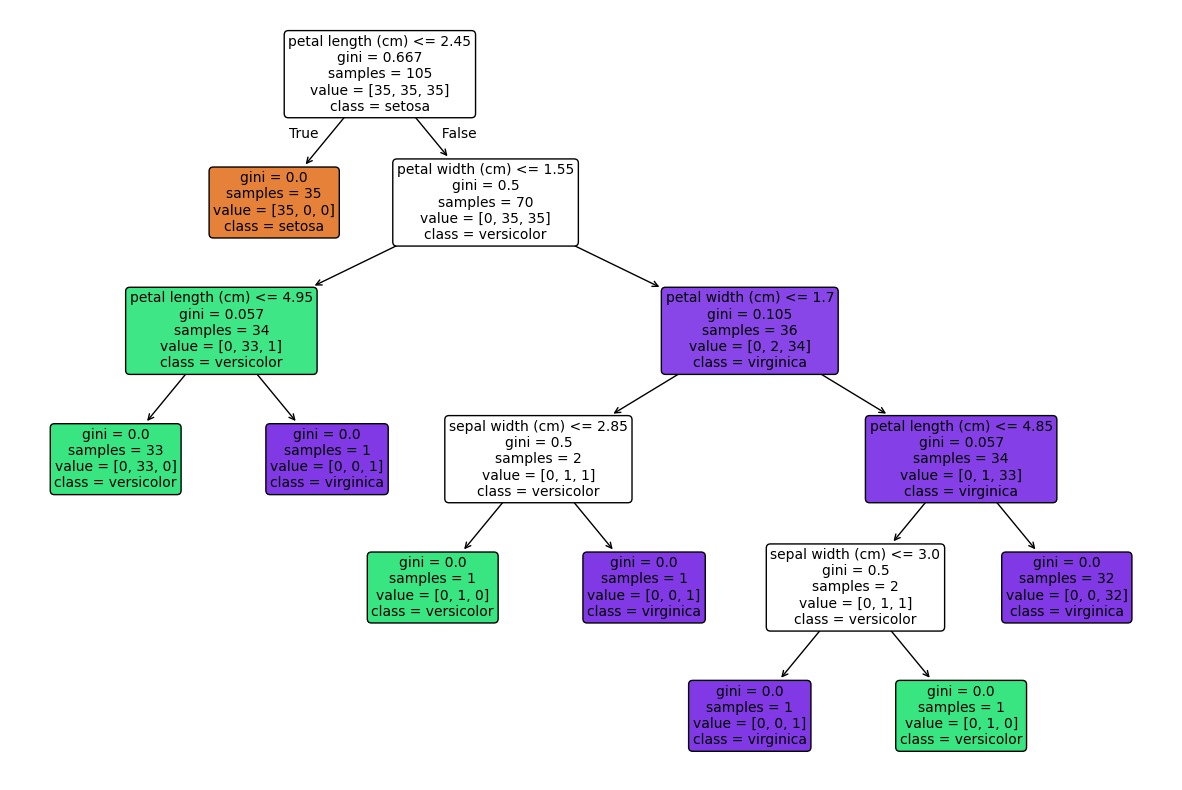

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Configurando o tamanho da imagem para melhor leitura
plt.figure(figsize=(15, 10))

# Plotando a árvore
plot_tree(clf, 
          feature_names=iris.feature_names, 
          class_names=list(iris.target_names), 
          filled=True, 
          rounded=True,
          fontsize=10)

plt.show()

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from IPython.display import display 

# Lista de profundidades solicitadas
profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]
resultados = []

for depth in profundidades:
    # Instanciar e treinar o modelo
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    # Fazer predições
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    
    # Coletar métricas (mantendo como números, não como strings)
    res = {
        "Max Depth": "None" if depth is None else depth,
        "Acurácia Treino": accuracy_score(y_train, y_pred_train),
        "Acurácia Teste": accuracy_score(y_test, y_pred_test),
        "Prof. Real": clf.get_depth(),
        "Nº de Folhas": clf.get_n_leaves()
    }
    resultados.append(res)

# Criar o DataFrame
df_resultados = pd.DataFrame(resultados)


# Exibe a tabela renderizada
display(df_resultados)

,Max Depth,Acurácia Treino,Acurácia Teste,Prof. Real,Nº de Folhas
0,1,0.666667,0.666667,1,2
1,2,0.971429,0.888889,2,3
2,3,0.980952,0.977778,3,5
3,4,0.990476,0.888889,4,7
4,5,1.000000,0.933333,5,8
5,6,1.000000,0.933333,5,8
6,7,1.000000,0.933333,5,8
7,8,1.000000,0.933333,5,8
8,9,1.000000,0.933333,5,8
9,None,1.000000,0.933333,5,8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

Ele começa o overfitting de 5 para 6
Pq ele chegou no final e para isso ele tem que atingir 100%


# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Lista com os dois critérios que queremos testar
criterios = ["gini", "entropy"]
resultados_criterios = []

for criterio in criterios:
    # Instanciar e treinar o modelo
    clf = DecisionTreeClassifier(criterion=criterio, random_state=42)
    clf.fit(X_train, y_train)
    
    # Fazer predições no conjunto de teste
    y_pred_test = clf.predict(X_test)
    
    # Coletar a profundidade e a acurácia
    resultados_criterios.append({
        "Critério": criterio,
        "Profundidade da Árvore": clf.get_depth(),
        "Acurácia (Teste)": accuracy_score(y_test, y_pred_test)
    })


df_comparacao = pd.DataFrame(resultados_criterios)



display(df_comparacao)

,Critério,Profundidade da Árvore,Acurácia (Teste)
0,gini,5,0.933333
1,entropy,6,0.888889


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [30]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Valores que vamos testar para min_samples_leaf (de 1 a 10)
valores_leaf = range(1, 11)
resultados_leaf = []

for min_leaf in valores_leaf:
    # Instanciando e treinando o modelo com o hiperparâmetro alterado
    clf = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    clf.fit(X_train, y_train)
    
    # Coletando métricas
    acc_train = accuracy_score(y_train, clf.predict(X_train))
    acc_test = accuracy_score(y_test, clf.predict(X_test))
    
    resultados_leaf.append({
        "min_samples_leaf": min_leaf,
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test,
        "Profundidade": clf.get_depth()
    })

# Transformando em DataFrame
df_leaf = pd.DataFrame(resultados_leaf)

# Encontrando o melhor modelo (maior acurácia de teste)
melhor_modelo = df_leaf.loc[df_leaf['Acurácia Teste'].idxmax()]

# Exibindo os resultados completos formatados
display(df_leaf)

display(melhor_modelo)

,min_samples_leaf,Acurácia Treino,Acurácia Teste,Profundidade
0,1,1.000000,0.933333,5
1,2,0.971429,0.888889,4
2,3,0.980952,0.844444,4
3,4,0.971429,0.888889,4
4,5,0.971429,0.888889,3
5,6,0.971429,0.888889,3
6,7,0.971429,0.888889,3
7,8,0.971429,0.888889,3
8,9,0.971429,0.888889,3
9,10,0.971429,0.888889,3


min_samples_leaf    1.000000
Acurácia Treino     1.000000
Acurácia Teste      0.933333
Profundidade        5.000000
Name: 0, dtype: float64